# 00 · Data Overview

Notebook base para entender el dataset, revisar la variable objetivo y dejar preparadas las decisiones de modelado comparables entre enfoques espaciales y no lineales.

## Objetivos

- Revisar calidad y cobertura de datos.
- Inspeccionar la distribución de `precio_m2` o su transformación.
- Explorar patrones espaciales iniciales.
- Detectar variables candidatas y potenciales sesgos del dataset.
- Dejar documentadas hipótesis para los notebooks de modelado.

In [9]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "00_data_overview"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)
PROJECT_ROOT

PosixPath('/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres')

## Carga de datos

Se cargan los datos procesados de `data/processed`: alquiler (`arg_alquiler_dat_processed.csv`) y venta (`arg_venta_data_processed.csv`). El análisis principal se enfoca en el dataset de venta.

Resumen rápido:
- `arg_alquiler_data_processed.csv`: 989 filas x 31 columnas.
- `arg_venta_data_processed.csv`: 10614 filas x 31 columnas.
- Objetivo base para modelado: `precio_sobre_m2`.
- Coordenadas espaciales: `longitud`, `latitud`.
- Variables con nulos importantes: `tipo_unidad`, `antiguedad`, `estado`, `disposicion`, `orientacion`, `estado_edificio`.


In [10]:
DATA_DIR = PROJECT_ROOT / "data" / "processed"
rental_path = DATA_DIR / "arg_alquiler_data_processed.csv"
sale_path = DATA_DIR / "arg_venta_data_processed.csv"

with pd.option_context("display.max_columns", 200):
    df_rental = pd.read_csv(rental_path)
    df_sale = pd.read_csv(sale_path)

# Dataset principal para análisis de venta.
df = df_sale
df["precio_sobre_m2"] = df["precio"] / df["area_m2_total"]
target_col = "precio_sobre_m2"
coord_cols = ["longitud", "latitud"]
id_col = "id"

print("Dataset de alquileres:", df_rental.shape)
print("Dataset de venta:", df_sale.shape)
print("Columnas comunes entre ambos datasets:")
print(sorted(set(df_rental.columns) & set(df_sale.columns)))

print("Primeras filas del dataset de venta:")
display(df_sale.head(3))


Dataset de alquileres: (3155, 47)
Dataset de venta: (33389, 48)
Columnas comunes entre ambos datasets:
['ambientes', 'antiguedad', 'antiguedad_cat', 'area_m2_cubierta', 'area_m2_descubierta', 'area_m2_total', 'area_metro', 'banos', 'barrio', 'cocheras', 'comuna', 'disposicion', 'disposicion_Contrafrente', 'disposicion_Frente', 'disposicion_Interno', 'disposicion_Lateral', 'dist_est_educativo', 'dist_hospital', 'dist_subte', 'dist_universidad', 'dormitorios', 'estado', 'estado_edificio', 'estado_num', 'expensas', 'id_left', 'id_right', 'idx', 'image_url', 'imagen_path', 'latitud', 'log_precio', 'longitud', 'moneda', 'nearest_est_educativo', 'nearest_hospital', 'nearest_subte', 'nearest_universidad', 'objeto', 'orientacion', 'perimetro_', 'precio', 'split', 'tipo_unidad', 'url', 'valido_desde', 'valido_hasta']
Primeras filas del dataset de venta:


,idx,id_left,url,precio,moneda,expensas,tipo_unidad,area_m2_cubierta,area_m2_descubierta,area_m2_total,antiguedad,estado_edificio,ambientes,banos,estado,disposicion,orientacion,latitud,longitud,image_url,imagen_path,valido_desde,valido_hasta,cocheras,dormitorios,id_right,objeto,barrio,comuna,perimetro_,area_metro,antiguedad_cat,dist_subte,nearest_subte,dist_universidad,nearest_universidad,dist_hospital,nearest_hospital,dist_est_educativo,nearest_est_educativo,estado_num,disposicion_Frente,disposicion_Contrafrente,disposicion_Lateral,disposicion_Interno,log_precio,split,precio_sobre_m2
0,39619,19293764.0,https://www.argenprop.com/departamento-en-vent...,600000.0,USD,3.281199,NaN,162.0,9.545268,-0.99266,3.112320,0.0,3.124738,-0.096299,Excelente,Frente,NaN,-34.591331,-58.412136,https://www.argenprop.com/static-content/46739...,NaN,2026-04-11 06:04:36.213880,NaN,-0.080154,4.0,21.0,BARRIO,Palermo,14.0,22830.60,15922586.17,80,352.540191,Bulnes,440.965965,Universidad de Palermo,2.217785e+06,Hospital Especializado de Gastroenterologia B....,190983.101533,Establecimiento educativo CARLOS PELLEGRINI,5,1,0,0,0,13.304687,train,-604436.546344
1,16774,16545893.0,https://www.argenprop.com/departamento-en-vent...,725000.0,USD,-0.769543,NaN,152.0,-0.409596,-0.99266,-0.783907,0.0,2.245095,-0.096299,Excelente,Frente,NaN,-34.573979,-58.474483,https://www.argenprop.com/static-content/39854...,NaN,2026-03-20 15:00:31.973124,2026-04-11 05:56:01.489403,-0.080154,4.0,48.0,BARRIO,Villa Urquiza,12.0,10021.46,5449059.44,11,733.317932,Echeverría - Mártires Palotinos,792.986437,Universidad de Buenos Aires,2.222095e+06,Hospital Especializado de Gastroenterologia B....,185516.090856,Establecimiento educativo CARLOS PELLEGRINI,5,1,0,0,0,13.493928,train,-730360.826832
2,8732,18380773.0,https://www.argenprop.com/departamento-en-vent...,39500.0,USD,-0.318664,NaN,20.0,-0.409596,-0.99266,0.212650,0.0,-1.273475,-0.096299,Excelente,Frente,NaN,-34.623142,-58.393307,https://www.argenprop.com/static-content/37708...,images/18380773.jpg,2026-03-13 01:59:43.348088,2026-04-11 05:47:27.559897,-0.080154,0.0,31.0,BARRIO,San Cristobal,3.0,5987.23,2043711.31,28,170.610429,Entre Rios - Rodolfo Walsh,862.253580,Universidad Argentina John F. Kennedy,2.217772e+06,Hospital Especializado de Gastroenterologia B....,192374.434144,Establecimiento educativo CARLOS PELLEGRINI,5,1,0,0,0,10.584081,train,-39792.072634


## Visualización 

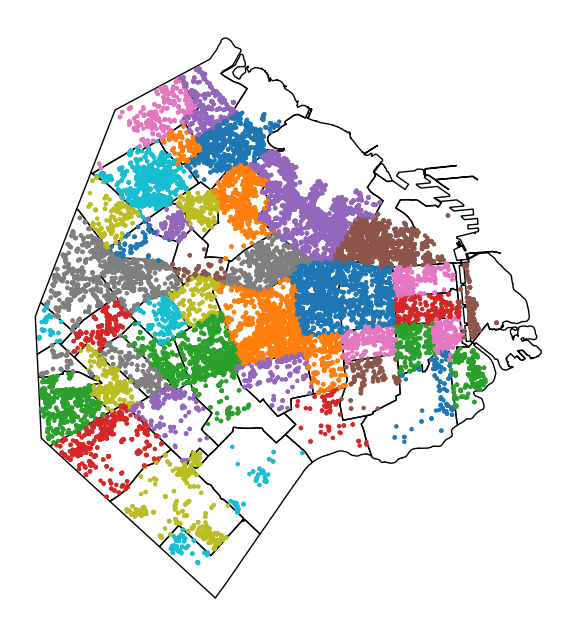

In [11]:

barrios = gpd.read_file(PROJECT_ROOT / "GeoData" / "barrios.geojson")

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitud, df.latitud),
    crs='EPSG:4326'
)

barrios = barrios.to_crs(gdf.crs)

fig, ax = plt.subplots(figsize=(8, 8))
barrios.plot(ax=ax, edgecolor='black', facecolor='none')

gdf.plot(
    ax=ax,
    column='barrio',
    markersize=5,
    legend=False,
)

ax.set_axis_off()
plt.show()


In [18]:
gdf.columns


Index(['idx', 'id_left', 'url', 'precio', 'moneda', 'expensas', 'tipo_unidad',
       'area_m2_cubierta', 'area_m2_descubierta', 'area_m2_total',
       'antiguedad', 'estado_edificio', 'ambientes', 'banos', 'estado',
       'disposicion', 'orientacion', 'latitud', 'longitud', 'image_url',
       'imagen_path', 'valido_desde', 'valido_hasta', 'cocheras',
       'dormitorios', 'id_right', 'objeto', 'barrio', 'comuna', 'perimetro_',
       'area_metro', 'antiguedad_cat', 'dist_subte', 'nearest_subte',
       'dist_universidad', 'nearest_universidad', 'dist_hospital',
       'nearest_hospital', 'dist_est_educativo', 'nearest_est_educativo',
       'estado_num', 'disposicion_Frente', 'disposicion_Contrafrente',
       'disposicion_Lateral', 'disposicion_Interno', 'log_precio', 'split',
       'precio_sobre_m2', 'geometry'],
      dtype='str')

## Sanity checks iniciales

In [12]:
for name, dataset in [("Alquiler", df_rental), ("Venta", df_sale)]:
    print(f"--- {name} ---")
    print("shape:", dataset.shape)
    print("columnas:", len(dataset.columns))
    print("nulos por columna (%):")
    display((dataset.isna().mean().sort_values(ascending=False) * 100).head(20))
    print("\nTipos de datos:")
    display(dataset.dtypes.sort_index())
    print("\n")

print("Dataset principal para análisis inicial: venta")
print("Columnas objetivo y espaciales:")
print("target_col:", target_col)
print("coord_cols:", coord_cols)
print("id_col:", id_col)

print("Resumen estadístico rápido del dataset de venta:")
display(df.describe(include="all").T.head(20))


--- Alquiler ---
shape: (3155, 47)
columnas: 47
nulos por columna (%):


orientacion            54.453249
valido_hasta           30.554675
tipo_unidad            21.014263
imagen_path             0.316957
url                     0.000000
valido_desde            0.000000
id_left                 0.000000
moneda                  0.000000
expensas                0.000000
area_m2_cubierta        0.000000
area_m2_descubierta     0.000000
area_m2_total           0.000000
antiguedad              0.000000
precio                  0.000000
idx                     0.000000
ambientes               0.000000
estado_edificio         0.000000
estado                  0.000000
banos                   0.000000
cocheras                0.000000
dtype: float64


Tipos de datos:


ambientes                   float64
antiguedad                  float64
antiguedad_cat                int64
area_m2_cubierta            float64
area_m2_descubierta         float64
area_m2_total               float64
area_metro                  float64
banos                       float64
barrio                          str
cocheras                    float64
comuna                      float64
disposicion                     str
disposicion_Contrafrente      int64
disposicion_Frente            int64
disposicion_Interno           int64
disposicion_Lateral           int64
dist_est_educativo          float64
dist_hospital               float64
dist_subte                  float64
dist_universidad            float64
dormitorios                 float64
estado                          str
estado_edificio             float64
estado_num                    int64
expensas                    float64
id_left                     float64
id_right                    float64
idx                         



--- Venta ---
shape: (33389, 48)
columnas: 48
nulos por columna (%):


orientacion            97.214652
tipo_unidad            97.181707
imagen_path            80.676271
valido_hasta           48.153584
image_url               0.041930
idx                     0.000000
url                     0.000000
id_left                 0.000000
area_m2_descubierta     0.000000
area_m2_total           0.000000
antiguedad              0.000000
estado_edificio         0.000000
precio                  0.000000
moneda                  0.000000
expensas                0.000000
area_m2_cubierta        0.000000
disposicion             0.000000
estado                  0.000000
banos                   0.000000
ambientes               0.000000
dtype: float64


Tipos de datos:


ambientes                   float64
antiguedad                  float64
antiguedad_cat                int64
area_m2_cubierta            float64
area_m2_descubierta         float64
area_m2_total               float64
area_metro                  float64
banos                       float64
barrio                          str
cocheras                    float64
comuna                      float64
disposicion                     str
disposicion_Contrafrente      int64
disposicion_Frente            int64
disposicion_Interno           int64
disposicion_Lateral           int64
dist_est_educativo          float64
dist_hospital               float64
dist_subte                  float64
dist_universidad            float64
dormitorios                 float64
estado                          str
estado_edificio             float64
estado_num                    int64
expensas                    float64
id_left                     float64
id_right                    float64
idx                         



Dataset principal para análisis inicial: venta
Columnas objetivo y espaciales:
target_col: precio_sobre_m2
coord_cols: ['longitud', 'latitud']
id_col: id
Resumen estadístico rápido del dataset de venta:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
idx,33389.0,NaN,NaN,NaN,22897.483183,10728.297002,4257.0,13714.0,22552.0,32280.0,41567.0
id_left,33389.0,NaN,NaN,NaN,17810182.714427,2419796.754941,2321489.0,17756634.0,18598365.0,19108987.0,19471604.0
url,33389,17060,https://www.argenprop.com/departamento-en-vent...,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precio,33389.0,NaN,NaN,NaN,162408.250142,126414.217424,35000.0,84000.0,125000.0,190000.0,950000.0
moneda,33389,3,USD,33344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expensas,33389.0,NaN,NaN,NaN,-0.000385,1.000129,-0.769543,-0.769543,-0.227367,0.352201,5.462369
tipo_unidad,941,8,Departamento,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_m2_cubierta,33389.0,NaN,NaN,NaN,57.474861,35.915042,0.0,36.0,49.0,70.0,720.0
area_m2_descubierta,33389.0,NaN,NaN,NaN,-0.000393,1.003774,-0.409596,-0.409596,-0.409596,-0.009948,14.123053
area_m2_total,33389.0,NaN,NaN,NaN,-0.000984,1.00115,-0.99266,-0.99266,-0.076485,0.534299,4.504392


## Variable objetivo

Explorá tanto la escala original como una posible transformación logarítmica si después la vas a usar en todos los modelos.

/home/saneliges/Escritorio/PredictorPrecioMetroCuadradoAlquileres/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


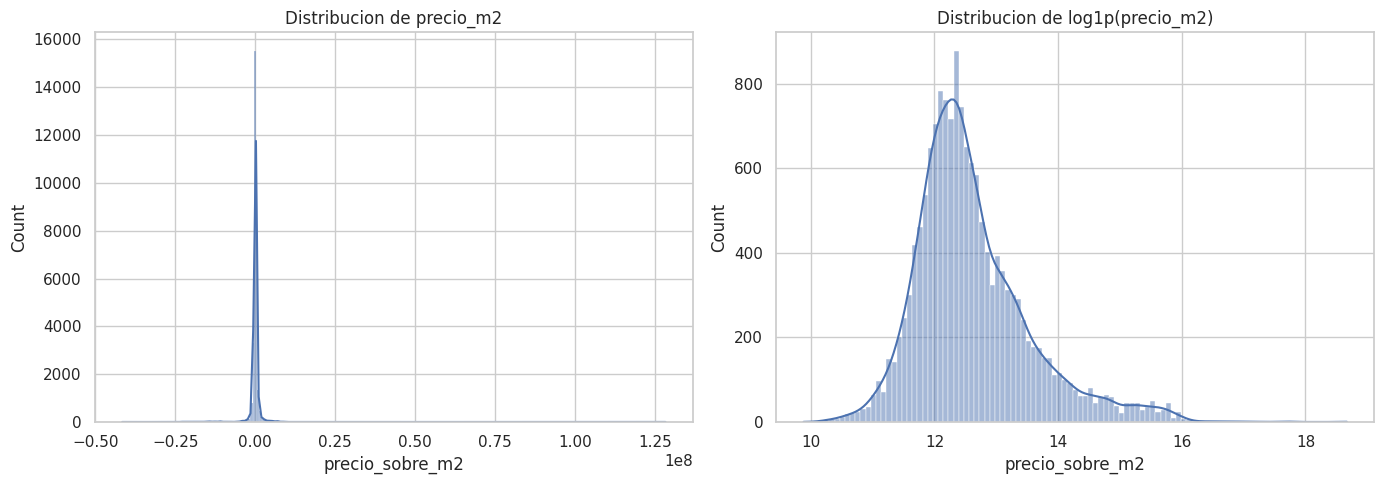

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[target_col], kde=True, ax=axes[0])
axes[0].set_title("Distribucion de precio_m2")
sns.histplot(np.log1p(df[target_col]), kde=True, ax=axes[1])
axes[1].set_title("Distribucion de log1p(precio_m2)")
plt.tight_layout()

## Exploración espacial

Acá conviene mirar mapas simples, densidad por zona y gradientes espaciales del target.

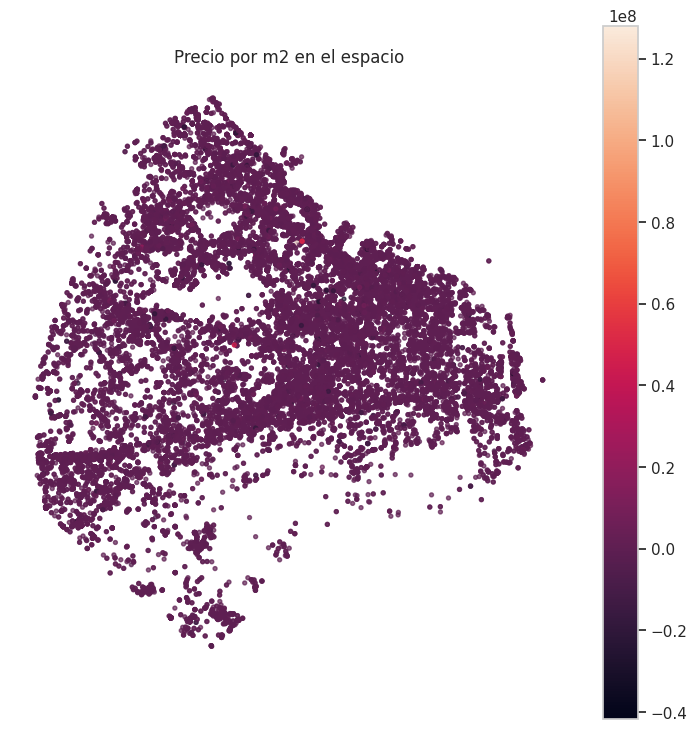

In [14]:
import geopandas as gpd
gdf = gpd.GeoDataFrame(df.copy(), geometry=gpd.points_from_xy(df[coord_cols[0]], df[coord_cols[1]]), crs="EPSG:4326")
ax = gdf.plot(column=target_col, figsize=(9, 9), alpha=0.7, markersize=8, legend=True)
ax.set_title("Precio por m2 en el espacio")
ax.set_axis_off()

## Correlaciones y señales candidatas

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr(numeric_only=True)[target_col].sort_values(ascending=False)
display(corr.head(20))
display(corr.tail(20))

precio_sobre_m2             1.000000
area_m2_total               0.070774
ambientes                   0.053119
dormitorios                 0.050963
log_precio                  0.036470
area_m2_cubierta            0.023362
precio                      0.023281
dist_hospital               0.022135
banos                       0.013940
area_m2_descubierta         0.012855
comuna                      0.012123
dist_universidad            0.011437
area_metro                  0.011119
dist_subte                  0.011049
id_right                    0.010007
estado_num                  0.008849
expensas                    0.006932
cocheras                    0.006585
perimetro_                  0.005297
disposicion_Contrafrente    0.002448
Name: precio_sobre_m2, dtype: float64

dist_universidad            0.011437
area_metro                  0.011119
dist_subte                  0.011049
id_right                    0.010007
estado_num                  0.008849
expensas                    0.006932
cocheras                    0.006585
perimetro_                  0.005297
disposicion_Contrafrente    0.002448
latitud                     0.001667
disposicion_Frente          0.001484
antiguedad_cat              0.001339
idx                         0.001252
antiguedad                  0.001186
disposicion_Interno        -0.000258
disposicion_Lateral        -0.006415
id_left                    -0.007875
dist_est_educativo         -0.024861
longitud                   -0.025223
estado_edificio                  NaN
Name: precio_sobre_m2, dtype: float64

## Hallazgos e hipótesis

- ¿Qué señales parecen más explicativas?
- ¿Dónde hay heterogeneidad espacial visible?
- ¿Qué outliers conviene tratar antes del modelado?
- ¿Qué variables deberían estar sí o sí en todos los modelos?